In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             r2_score)
import pickle
import datetime

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [ ]:
url = "https://raw.githubusercontent.com/abhijeetnst/property-prediction/main/kc_house_data.csv"
df = pd.read_csv(url)

In [ ]:
df.shape

(21613, 21)

In [ ]:
column_info = {
    'id':             'Unique house identifier (not useful for prediction)',
    'date':           'Date the house was sold',
    'price':          '🎯 TARGET – Sale price of the house ($)',
    'bedrooms':       'Number of bedrooms',
    'bathrooms':      'Number of bathrooms (0.5 = half bath)',
    'sqft_living':    'Interior square footage of the house',
    'sqft_lot':       'Total lot size in square feet',
    'floors':         'Number of floors',
    'waterfront':     '1 = has waterfront view, 0 = no',
    'view':           'View quality score (0-4)',
    'condition':      'Physical condition of house (1-5)',
    'grade':          'King County building grade (1-13)',
    'sqft_above':     'Square footage above ground',
    'sqft_basement':  'Square footage of basement',
    'yr_built':       'Year the house was built',
    'yr_renovated':   'Year of last renovation (0 = never renovated)',
    'zipcode':        'Zip code of the property location',
    'lat':            'Latitude (geographic coordinate)',
    'long':           'Longitude (geographic coordinate)',
    'sqft_living15':  'Average living area of 15 nearest neighbors',
    'sqft_lot15':     'Average lot area of 15 nearest neighbors'
}

for col, meaning in column_info.items():
    print(f"  {col:<18} → {meaning}")

  id                 → Unique house identifier (not useful for prediction)
  date               → Date the house was sold
  price              → 🎯 TARGET – Sale price of the house ($)
  bedrooms           → Number of bedrooms
  bathrooms          → Number of bathrooms (0.5 = half bath)
  sqft_living        → Interior square footage of the house
  sqft_lot           → Total lot size in square feet
  floors             → Number of floors
  waterfront         → 1 = has waterfront view, 0 = no
  view               → View quality score (0-4)
  condition          → Physical condition of house (1-5)
  grade              → King County building grade (1-13)
  sqft_above         → Square footage above ground
  sqft_basement      → Square footage of basement
  yr_built           → Year the house was built
  yr_renovated       → Year of last renovation (0 = never renovated)
  zipcode            → Zip code of the property location
  lat                → Latitude (geographic coordinate)
  long      

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
print("=== STATISTICAL SUMMARY ===")
print(df.describe().round(2).to_string())

=== STATISTICAL SUMMARY ===
                 id       price  bedrooms  bathrooms  sqft_living    sqft_lot    floors  waterfront      view  condition     grade  sqft_above  sqft_basement  yr_built  yr_renovated   zipcode       lat      long  sqft_living15  sqft_lot15
count  2.161300e+04    21613.00  21613.00   21613.00     21613.00    21613.00  21613.00    21613.00  21613.00   21613.00  21613.00    21613.00       21613.00  21613.00      21613.00  21613.00  21613.00  21613.00       21613.00    21613.00
mean   4.580302e+09   540088.14      3.37       2.11      2079.90    15106.97      1.49        0.01      0.23       3.41      7.66     1788.39         291.51   1971.01         84.40  98077.94     47.56   -122.21        1986.55    12768.46
std    2.876566e+09   367127.20      0.93       0.77       918.44    41420.51      0.54        0.09      0.77       0.65      1.18      828.09         442.58     29.37        401.68     53.51      0.14      0.14         685.39    27304.18
min    1.000102e

In [ ]:
print("=== MISSING VALUES PER COLUMN ===")
missing = df.isnull().sum()
print(missing[missing >= 0].to_string())

total_missing = missing.sum()
print(f"\nTotal missing values: {total_missing}")

=== MISSING VALUES PER COLUMN ===
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0

Total missing values: 0


In [ ]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicates. Remaining rows: {len(df)}")
else:
    print(" No duplicates found!")


Duplicate rows found: 0
 No duplicates found!


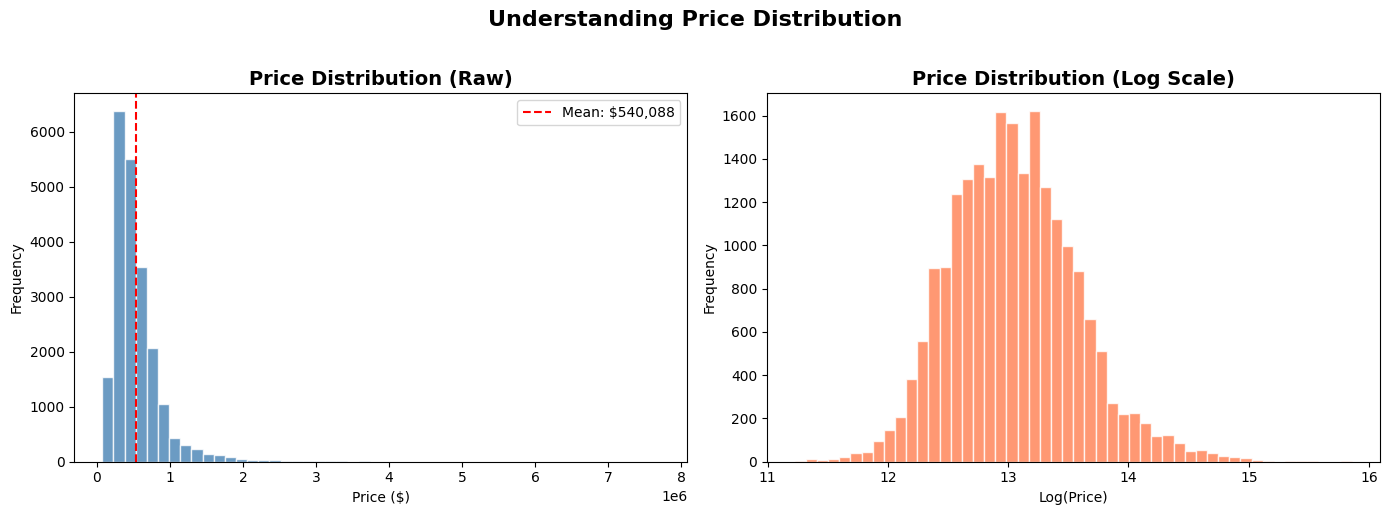

Price stats:
  Min    : $      75,000
  Max    : $   7,700,000
  Mean   : $     540,088
  Median : $     450,000
  Skew   : 4.02  (>1 = right skewed)


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Price Distribution (Raw)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f"Mean: ${df['price'].mean():,.0f}")
axes[0].legend()

axes[1].hist(np.log1p(df['price']), bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Price Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Understanding Price Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Price stats:")
print(f"  Min    : ${df['price'].min():>12,.0f}")
print(f"  Max    : ${df['price'].max():>12,.0f}")
print(f"  Mean   : ${df['price'].mean():>12,.0f}")
print(f"  Median : ${df['price'].median():>12,.0f}")
print(f"  Skew   : {df['price'].skew():.2f}  (>1 = right skewed)")



=== CORRELATION WITH PRICE ===
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203


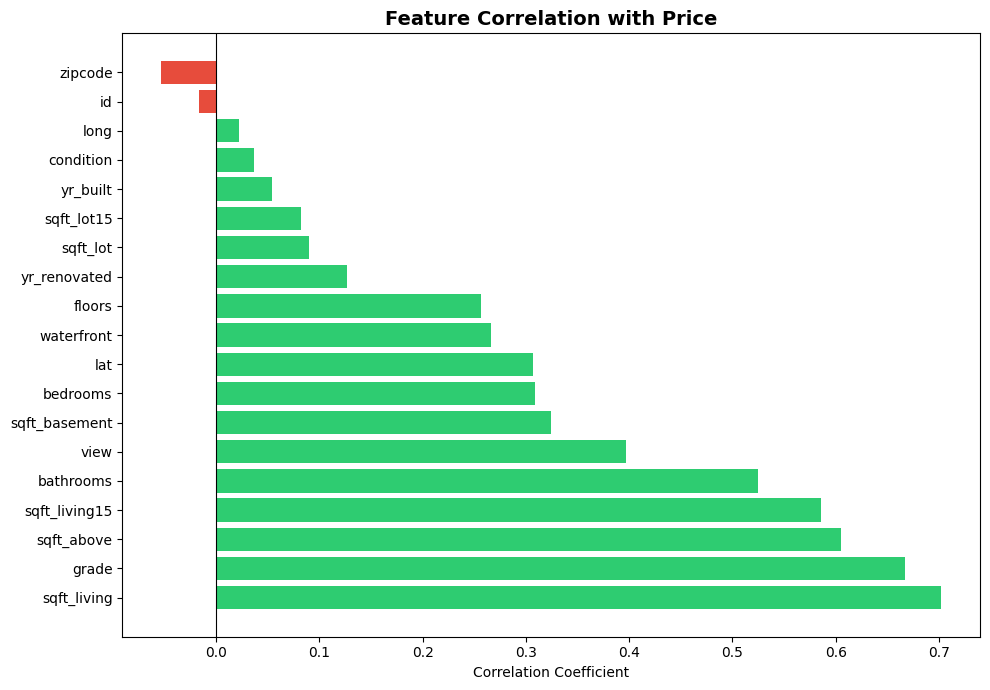

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
correlation_with_price = numeric_df.corr()['price'].sort_values(ascending=False)

print("=== CORRELATION WITH PRICE ===")
print(correlation_with_price.to_string())


fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in correlation_with_price.values[1:]]
ax.barh(correlation_with_price.index[1:], correlation_with_price.values[1:], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.savefig('correlation.png', dpi=150)
plt.show()

In [ ]:
print(f"Rows before outlier removal: {len(df)}")


print(f"\nHouses with >10 bedrooms: {len(df[df['bedrooms'] > 10])}")
print(df[df['bedrooms'] > 10][['price','bedrooms','sqft_living']])


df = df[df['bedrooms'] <= 10]


Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3.0 * IQR
upper_bound = Q3 + 3.0 * IQR

print(f"\nPrice outlier bounds:")
print(f"  Lower : ${lower_bound:,.0f}")
print(f"  Upper : ${upper_bound:,.0f}")

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
print(f"\nRows after outlier removal: {len(df)}")

Rows before outlier removal: 21613

Houses with >10 bedrooms: 2
          price  bedrooms  sqft_living
8757   520000.0        11         3000
15870  640000.0        33         1620

Price outlier bounds:
  Lower : $-648,100
  Upper : $1,614,825

Rows after outlier removal: 21191


In [ ]:

df['date'] = pd.to_datetime(df['date'])


df.drop(columns=['id'], inplace=True)
print("Dropped: id")

print(f"\nRemaining shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Dropped: id

Remaining shape: (21191, 20)
Columns: ['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [ ]:
current_year = datetime.datetime.now().year


df['house_age'] = current_year - df['yr_built']
print(f"house_age    → min:{df['house_age'].min()}, max:{df['house_age'].max()}, mean:{df['house_age'].mean():.1f}")


df['renovated'] = df['yr_renovated'].apply(lambda x: 0 if x == 0 else 1)
renovated_count = df['renovated'].sum()
print(f"renovated    → {renovated_count} houses renovated ({renovated_count/len(df)*100:.1f}%)")


df['amenity_score'] = df['waterfront'] + df['view'] + df['condition'] + df['grade']
print(f"amenity_score → min:{df['amenity_score'].min()}, max:{df['amenity_score'].max()}, mean:{df['amenity_score'].mean():.1f}")


df['price_per_sqft'] = df['price'] / df['sqft_living']
print(f"price_per_sqft → mean: ${df['price_per_sqft'].mean():.2f}")


df.drop(columns=['yr_renovated', 'date', 'yr_built'], inplace=True)

print(f"\nFinal shape after feature engineering: {df.shape}")
print(f"All columns: {list(df.columns)}")



house_age    → min:11, max:126, mean:55.1
renovated    → 848 houses renovated (4.0%)
amenity_score → min:2, max:21, mean:11.2
price_per_sqft → mean: $259.26

Final shape after feature engineering: (21191, 21)
All columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'renovated', 'amenity_score', 'price_per_sqft']


In [ ]:
X = df.drop(columns=['price', 'price_per_sqft'])
y = df['price']

print(f"Features (X) shape : {X.shape}")
print(f"Target (y) shape   : {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set  : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")

train_with_price = X_train.copy()
train_with_price['price'] = y_train.values


zipcode_mean = train_with_price.groupby('zipcode')['price'].mean()
print(f"\nZipcode encoding stats:")
print(f"  Unique zipcodes in train : {len(zipcode_mean)}")
print(f"  Lowest mean price  : ${zipcode_mean.min():,.0f} (zipcode {zipcode_mean.idxmin()})")
print(f"  Highest mean price : ${zipcode_mean.max():,.0f} (zipcode {zipcode_mean.idxmax()})")


X_train = X_train.copy()
X_test  = X_test.copy()

X_train['zipcode_encoded'] = X_train['zipcode'].map(zipcode_mean)
X_test['zipcode_encoded']  = X_test['zipcode'].map(zipcode_mean)


global_mean_price = y_train.mean()
X_test['zipcode_encoded'].fillna(global_mean_price, inplace=True)


X_train.drop(columns=['zipcode'], inplace=True)
X_test.drop(columns=['zipcode'], inplace=True)

print(f"\nX_train after encoding: {X_train.shape}")
print(X_train.head(3))

Features (X) shape : (21191, 19)
Target (y) shape   : (21191,)

Feature columns: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'renovated', 'amenity_score']

Train set : 16,952 rows (80%)
Test set  : 4,239 rows (20%)

Zipcode encoding stats:
  Unique zipcodes in train : 70
  Lowest mean price  : $234,120 (zipcode 98002)
  Highest mean price : $1,218,692 (zipcode 98039)

X_train after encoding: (16952, 19)
       bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
18639         3       2.75         1690      5763     1.0           0     0   
3348          4       2.50         2370      9679     2.0           0     0   
6784          4       1.75         2360      6000     1.0           0     0   

       condition  grade  sqft_above  sqft_basement      lat     long  \
18639          5      7        1180     

In [ ]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

feature_names = list(X_train.columns)

print("✅ Feature scaling complete!")
print(f"Feature count : {len(feature_names)}")
print(f"Features      : {feature_names}")
print(f"\nBefore scaling (sqft_living): {X_train['sqft_living'].mean():.1f}")
print(f"After scaling  (sqft_living): {X_train_scaled[:, feature_names.index('sqft_living')].mean():.4f}")



✅ Feature scaling complete!
Feature count : 19
Features      : ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'renovated', 'amenity_score', 'zipcode_encoded']

Before scaling (sqft_living): 2030.4
After scaling  (sqft_living): 0.0000


In [ ]:

print("Training Linear Regression...")

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("\n" + "="*45)
print("  LINEAR REGRESSION RESULTS")
print("="*45)
print(f"  MAE   : ${mae_lr:>12,.0f}  ← avg error per house")
print(f"  RMSE  : ${rmse_lr:>12,.0f}  ← sensitive to big errors")
print(f"  R²    : {r2_lr:>13.4f}  ← 1.0 = perfect prediction")
print("="*45)


coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print("\nTop 5 Most Important Features (Linear Regression):")
print(coef_df.head(5).to_string(index=False))



Training Linear Regression...

  LINEAR REGRESSION RESULTS
  MAE   : $      78,245  ← avg error per house
  RMSE  : $     111,196  ← sensitive to big errors
  R²    :        0.8107  ← 1.0 = perfect prediction

Top 5 Most Important Features (Linear Regression):
        Feature   Coefficient
zipcode_encoded 114272.925460
    sqft_living  49954.691169
     sqft_above  47011.853026
          grade  36921.731078
  amenity_score  33972.424174


In [ ]:

print("Training Random Forest (may take 1-2 minutes)...")

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
print("✅ Training complete!")

y_pred_rf = rf_model.predict(X_test_scaled)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("\n" + "="*45)
print("  RANDOM FOREST RESULTS")
print("="*45)
print(f"  MAE   : ${mae_rf:>12,.0f}")
print(f"  RMSE  : ${rmse_rf:>12,.0f}")
print(f"  R²    : {r2_rf:>13.4f}")
print("="*45)



Training Random Forest (may take 1-2 minutes)...
✅ Training complete!

  RANDOM FOREST RESULTS
  MAE   : $      60,756
  RMSE  : $      94,205
  R²    :        0.8641


=== MODEL COMPARISON ===
  Metric Linear Regression Random Forest
 MAE ($)           $78,245       $60,756
RMSE ($)          $111,196       $94,205
R² Score            0.8107        0.8641

✅ Random Forest improves R² by 6.6% over Linear Regression
✅ Random Forest reduces MAE by $17,490


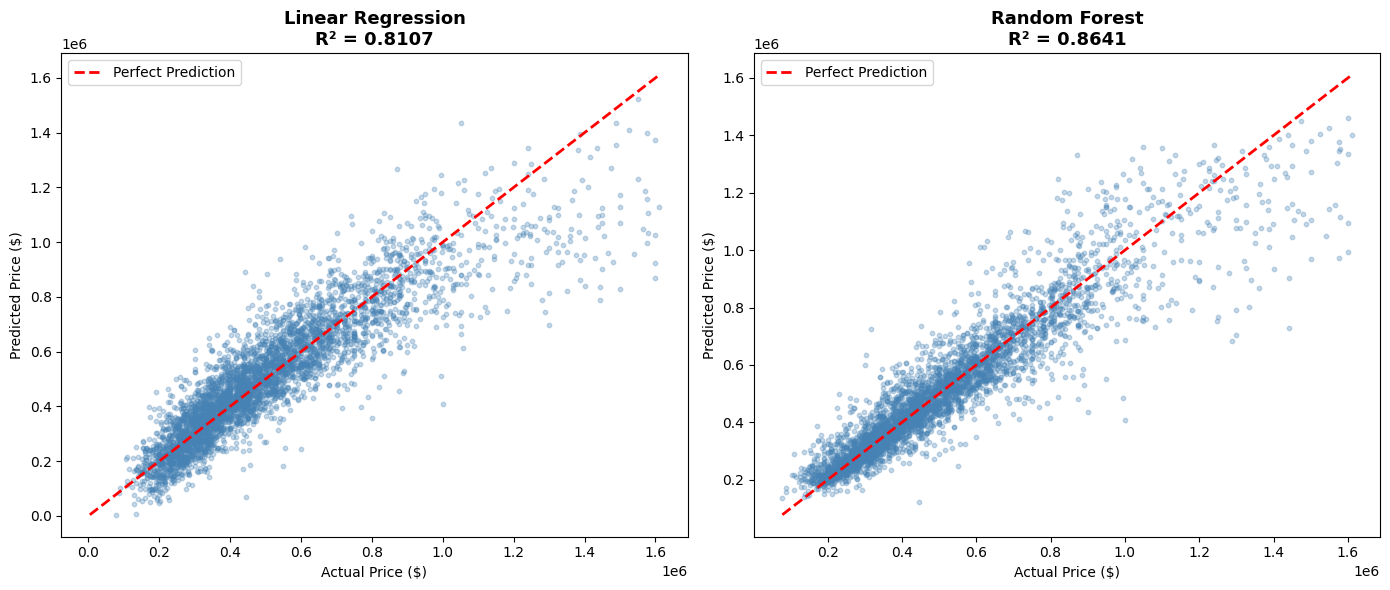

In [ ]:

comparison = pd.DataFrame({
    'Metric': ['MAE ($)', 'RMSE ($)', 'R² Score'],
    'Linear Regression': [f"${mae_lr:,.0f}", f"${rmse_lr:,.0f}", f"{r2_lr:.4f}"],
    'Random Forest':     [f"${mae_rf:,.0f}", f"${rmse_rf:,.0f}", f"{r2_rf:.4f}"]
})
print("=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))

improvement = (r2_rf - r2_lr) / r2_lr * 100
print(f"\n✅ Random Forest improves R² by {improvement:.1f}% over Linear Regression")
print(f"✅ Random Forest reduces MAE by ${mae_lr - mae_rf:,.0f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_rf],
                              ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.set_title(f'{title}\nR² = {r2_score(y_test, y_pred):.4f}', fontsize=13, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()



=== FEATURE IMPORTANCE RANKING ===
  grade                0.3512  ██████████████████████████████████████████████████████████████████████
  zipcode_encoded      0.2828  ████████████████████████████████████████████████████████
  sqft_living          0.1410  ████████████████████████████
  amenity_score        0.0526  ██████████
  long                 0.0368  ███████
  lat                  0.0334  ██████
  sqft_living15        0.0189  ███
  sqft_above           0.0175  ███
  house_age            0.0165  ███
  sqft_lot             0.0136  ██
  sqft_lot15           0.0105  ██
  view                 0.0061  █
  bathrooms            0.0054  █
  sqft_basement        0.0042  
  bedrooms             0.0026  
  waterfront           0.0025  
  floors               0.0017  
  condition            0.0017  
  renovated            0.0012  


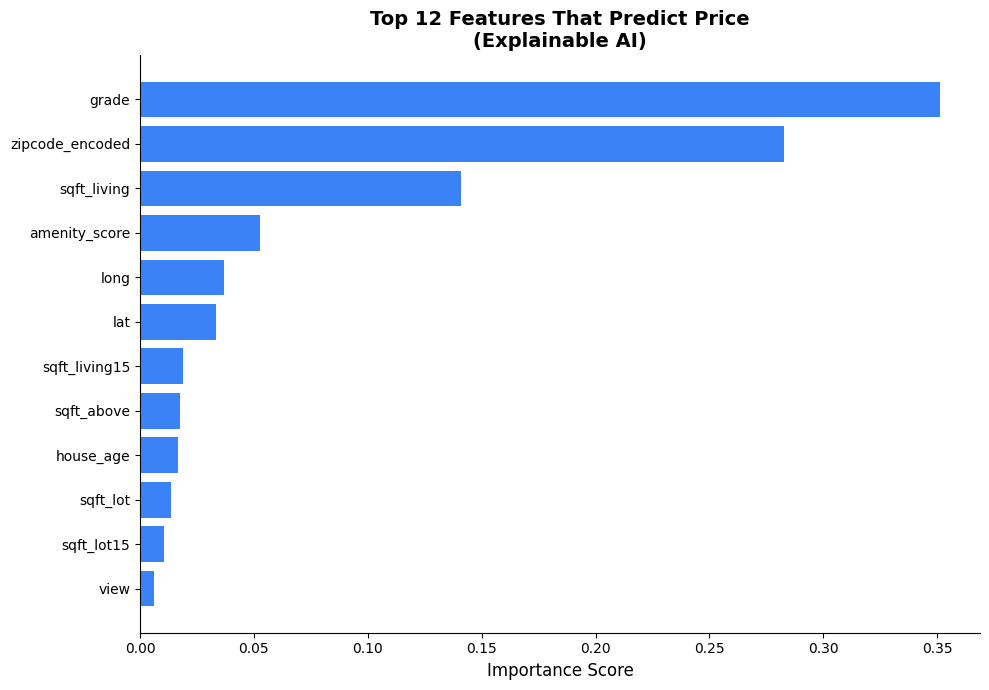

In [ ]:

feat_importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== FEATURE IMPORTANCE RANKING ===")
for i, row in feat_importance_df.iterrows():
    bar = "█" * int(row['Importance'] * 200)
    print(f"  {row['Feature']:<20} {row['Importance']:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(10, 7))
feat_top = feat_importance_df.head(12)
ax.barh(feat_top['Feature'][::-1], feat_top['Importance'][::-1], color='#3b82f6')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 12 Features That Predict Price\n(Explainable AI)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()



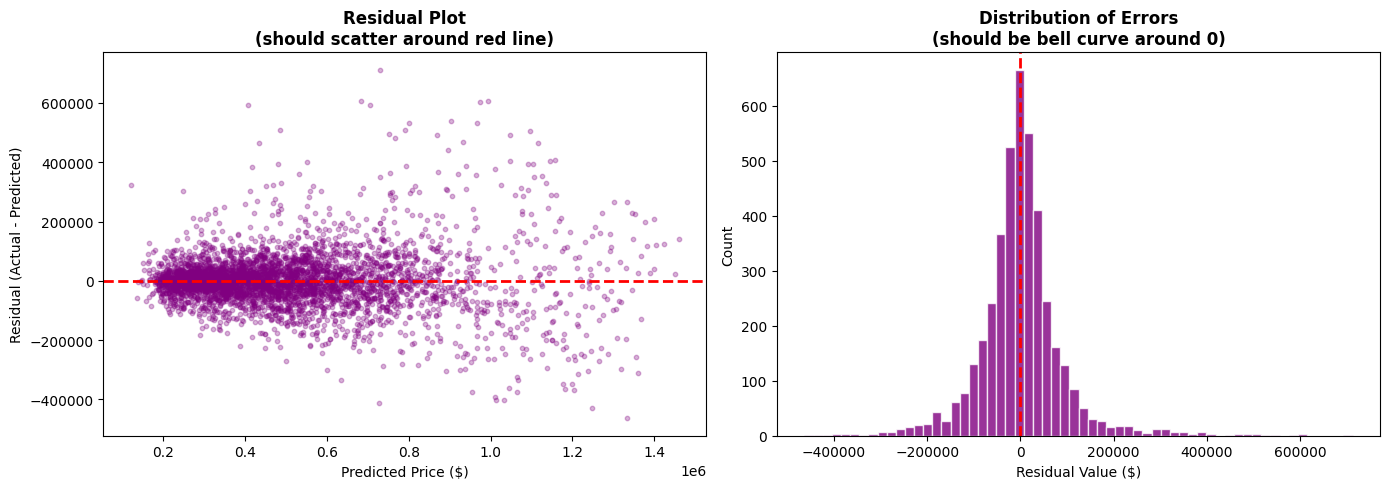

Mean Residual : $870  (should be close to 0)
Std Residual  : $94,201


In [ ]:

residuals = y_test.values - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_rf, residuals, alpha=0.3, color='purple', s=10)
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residual Plot\n(should scatter around red line)', fontsize=12, fontweight='bold')


axes[1].hist(residuals, bins=60, color='purple', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual Value ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Errors\n(should be bell curve around 0)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150)
plt.show()

print(f"Mean Residual : ${residuals.mean():,.0f}  (should be close to 0)")
print(f"Std Residual  : ${residuals.std():,.0f}")


In [ ]:

model_artifacts = {
    'model':         rf_model,
    'scaler':        scaler,
    'feature_names': feature_names,
    'zipcode_mean':  zipcode_mean,
    'current_year':  current_year
}

with open('model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

import os
size_mb = os.path.getsize('model.pkl') / (1024 * 1024)
print(f"✅ model.pkl saved successfully!")
print(f"   File size : {size_mb:.1f} MB")
print(f"   Contents  : {list(model_artifacts.keys())}")


✅ model.pkl saved successfully!
   File size : 96.3 MB
   Contents  : ['model', 'scaler', 'feature_names', 'zipcode_mean', 'current_year']


In [ ]:

sample_indices = [0, 10, 50, 100, 500]
print("=== SANITY CHECK – 5 Sample Predictions ===")
print(f"{'#':<5} {'Actual':>12} {'Predicted':>12} {'Error':>12} {'Error%':>8}")
print("-" * 55)

for i in sample_indices:
    actual    = y_test.iloc[i]
    sample    = X_test_scaled[i:i+1]
    predicted = rf_model.predict(sample)[0]
    error     = abs(actual - predicted)
    error_pct = error / actual * 100
    print(f"{i:<5} ${actual:>11,.0f} ${predicted:>11,.0f} ${error:>11,.0f} {error_pct:>7.1f}%")

print("\n✅ Model is working correctly!")



=== SANITY CHECK – 5 Sample Predictions ===
#           Actual    Predicted        Error   Error%
-------------------------------------------------------
0     $    470,500 $    574,087 $    103,587    22.0%
10    $    998,160 $  1,104,133 $    105,973    10.6%
50    $    361,280 $    356,900 $      4,380     1.2%
100   $    421,500 $    437,987 $     16,487     3.9%
500   $    415,000 $    387,719 $     27,281     6.6%

✅ Model is working correctly!


In [ ]:
from google.colab import files

print("Downloading files...")
files.download('model.pkl')
files.download('feature_importance.png')
files.download('actual_vs_predicted.png')
files.download('price_distribution.png')
print("✅ All files downloaded!")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
